Входные данные, в будущем лучше грузить из файла

In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

In [3]:
# My library imports
import fluid
from function_dp import vniigaz_vertical_one, vniigaz_vertical_two, vniigaz_inclined, vniigaz_horizontal

In [ ]:
# Исходные значения для расчёта
lyamda=0.0140
diameter=0.1000
alfa=45
v=1.95E-03
u=5.643
Ro_water=1000.00
Ro_gas=19.24764133
pressure=2.896463361
sigma=0.072
q_liquid=1.52778E-05
q_gas=1.273148148

# # -- Тестовые расчёты функции ВНИИГАЗ
# a parametrs for horizontal:
# idx = 465
# alfa = well_propertis.loc[idx, 'alfa']
# # q_liquid = 0.000138889
# q_liquid = ((Q_gas_std*1000/86400)*wgr)
# diameter = 0.1
# v = well_propertis.loc[idx, 'v']
# u = well_propertis.loc[idx, 'u']
# Ro_gas = well_propertis.loc[idx, 'Ro_gas']
# lyamda =0.02
# q_gas = well_propertis.loc[idx, 'Qgas_pt']
# print(alfa)

horizont = vniigaz_horizontal(lyamda, diameter, alfa, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
print("dp_dz from vniigaz_horizont:", horizont)

# inclined = vniigaz_inclined(lyamda, diameter, alfa, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_inclined:", inclined)

# vertical = vniigaz_vertical_one(lyamda, diameter, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_vertical_one:", vertical)

# vertical_two = vniigaz_vertical_two(lyamda, diameter, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_two:", vertical_two)


NameError: name 'well_propertis' is not defined

In [7]:
# Standard conditions
Pstd = 101325 #Pa
Tstd = 273.15 + 20 #K

# Fluid
Ro_gas_std = 0.67 # кг/м3
Ro_water_std = 1000 # кг/м3
sigma = 0.072 # Н/м, поверхностное натяжение

# Reservoir
permability = 10*10**-12 # м2
pay_thickness = 10 # м

reservoir_temp = 305.15 # K
wellhead_temp = 293.15 # K
reservoir_pressure = 4.446 # МПа

# Data for gas-liquid flow
Q_gas_std = 600 # тыс.м3/сутки
diameter = 0.1 # м, диаметр трубы
lyamda = 0.015
# wgr = 12*10**-5 # м3/м3, водогазовый фактор
wgr = 1e-6 # м3/м3, водогазовый фактор

In [5]:
# Well properties
# Download inclinometry data
file_path_incl = 'include/incl_17.dev'  # Update this path to match your actual file location
with open(file_path_incl, 'r', encoding='utf-8') as inclinometry_file:
    well_data = pd.read_csv(inclinometry_file, comment='#', sep=r'\s+')

# Download inclinometry data_horizontal
file_path_incl_horizontal = 'include/incl_10102.dev'  # Update this path to match your actual file location
with open(file_path_incl_horizontal, 'r', encoding='utf-8') as inclinometry_file_horizontal:
    well_data_hor = pd.read_csv(inclinometry_file_horizontal, comment='#', sep=r'\s+')

# Download inclinometry data full vertical well
file_path_incl_horizontal = 'include/incl_vertical.dev'  # Update this path to match your actual file location
with open(file_path_incl_horizontal, 'r', encoding='utf-8') as inclinometry_file_vert:
    well_data_vert = pd.read_csv(inclinometry_file_vert, comment='#', sep=r'\s+')


# Gas properties
# Download PVT data
file_path_pvt = 'include/PVT.inc'  # Update this path to match your actual file location
with open(file_path_pvt, 'r', encoding='utf-8') as pvt_file:
    pvt_data = pd.read_csv(pvt_file, comment='#', sep=r'\s+')

# Test fuid properties
# Create a fluid object with the given properties
# rho_c=0.6799, xa=0.8858, xy=0.0668
Ro_gas_std = 0.6799
xa = 0.8858
xy = 0.0668
fluid = fluid.Fluid(Ro_gas_std, xa, xy, pvt_data)

In [9]:
well_propertis = pd.DataFrame({
    'MD': well_data_vert['MD'],
    'TVD': well_data_vert['TVD'],
    'alfa': well_data_vert['INCL'],
    'Diameter': diameter,
    'T': np.nan,
    'z': np.nan,
    'Ro_gas': np.nan,
    'Qgas_pt': np.nan,
    'Dp_dz': np.nan,
})

In [15]:
# Расчёт градиента давления от забоя до устья
for idx in well_propertis.index[::-1]:

    # Заполнение параметра Т в зависимости от глубины скважины
    if idx == 0:
        well_propertis.loc[idx, 'T'] = wellhead_temp
    elif idx == len(well_propertis)-1:
        well_propertis.loc[idx, 'T'] = reservoir_temp
    else:
        well_propertis.loc[idx, 'T'] = reservoir_temp - (reservoir_temp - wellhead_temp) * (well_propertis.loc[idx, 'TVD'] / well_propertis['TVD'].iloc[-1])

    # Заполнение параметра Pi в зависимости от глубины скважины
    if idx == len(well_propertis)-1:
        well_propertis.loc[idx, 'Pi'] = reservoir_pressure

    tempreture = well_propertis.loc[idx, 'T'] # К
    pressure = well_propertis.loc[idx, 'Pi'] # МПа

    # Расчёт z
    if not pd.isna(well_propertis.loc[idx, 'Pi']):
        well_propertis.loc[idx, 'z'] = fluid.get_Z(pressure, tempreture)
        well_propertis.loc[idx, 'Ro_gas'] = fluid.get_ro(well_propertis.loc[idx, 'Pi'], well_propertis.loc[idx, 'T'])
        well_propertis.loc[idx, 'u'] = (Q_gas_std*1000/86400) * Ro_gas_std / well_propertis.loc[idx, 'Ro_gas'] / (np.pi*well_propertis.loc[idx, 'Diameter']**2/4)
        well_propertis.loc[idx, 'v'] = ((Q_gas_std*1000/86400)*wgr)/(np.pi*well_propertis.loc[idx, 'Diameter']**2/4)
        well_propertis.loc[idx, 'Qgas_pt'] = (Q_gas_std*1000/86400) * fluid.get_Bg(pressure, tempreture)
        if well_propertis.loc[idx, 'alfa'] < 84:
            well_propertis.loc[idx, 'Dp_dz'] = vniigaz_inclined(lyamda, diameter, well_propertis.loc[idx, 'alfa'], well_propertis.loc[idx, 'v'], well_propertis.loc[idx, 'u'], Ro_water_std, well_propertis.loc[idx, 'Ro_gas'], pressure, sigma, ((Q_gas_std*1000/86400)*wgr))
        else:
            well_propertis.loc[idx, 'Dp_dz'] = vniigaz_horizontal(lyamda, diameter, well_propertis.loc[idx, 'alfa'], well_propertis.loc[idx, 'v'], well_propertis.loc[idx, 'u'], Ro_water_std, well_propertis.loc[idx, 'Ro_gas'], pressure, sigma, ((Q_gas_std*1000/86400)*wgr))
        if idx > 0:
            well_propertis.loc[idx, 'Pi1'] = well_propertis.loc[idx, 'Pi'] - (well_propertis.loc[idx, 'Dp_dz'] * (well_propertis.loc[idx, 'MD'] - well_propertis.loc[idx-1, 'MD']))*10**-6     
            well_propertis.loc[idx-1, 'Pi'] = well_propertis.loc[idx, 'Pi1']

In [16]:
well_propertis.head(41)

,MD,TVD,alfa,Diameter,T,z,Ro_gas,Qgas_pt,Dp_dz,Pi,u,v,Pi1
0,0,0,0,0.1,293.15,0.947576,20.266043,0.232977,1532.046809,2.861900,29.231659,0.000884,NaN
1,30,30,0,0.1,304.85,0.954257,19.669387,0.240044,1565.593279,2.908868,30.118380,0.000884,2.861900
2,60,60,0,0.1,304.55,0.953372,20.021155,0.235827,1545.531336,2.955234,29.589205,0.000884,2.908868
3,90,90,0,0.1,304.25,0.952491,20.370277,0.231785,1526.423184,3.001027,29.082082,0.000884,2.955234
4,120,120,0,0.1,303.95,0.951612,20.716922,0.227907,1508.201966,3.046273,28.595468,0.000884,3.001027
5,150,150,0,0.1,303.65,0.950735,21.061247,0.224181,1490.807247,3.090997,28.127967,0.000884,3.046273
6,180,180,0,0.1,303.35,0.949861,21.403400,0.220597,1474.184247,3.135222,27.678315,0.000884,3.090997
7,210,210,0,0.1,303.05,0.948988,21.743521,0.217146,1458.283179,3.178971,27.245361,0.000884,3.135222
8,240,240,0,0.1,302.75,0.948117,22.081739,0.213820,1443.058684,3.222263,26.828053,0.000884,3.178971
9,270,270,0,0.1,302.45,0.947247,22.418178,0.210612,1428.469337,3.265117,26.425434,0.000884,3.222263


<function matplotlib.pyplot.show(close=None, block=None)>

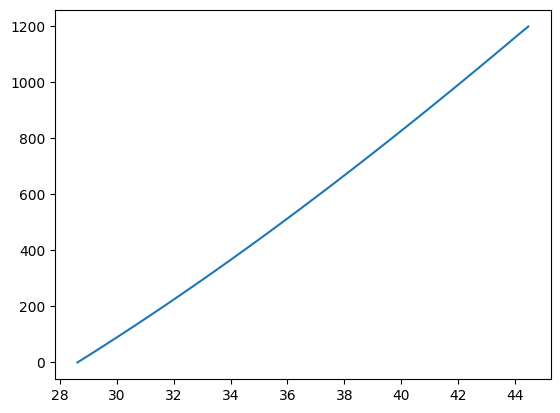

In [17]:
# well_propertis.to_csv("propertis", index=False, encoding="utf-8")
plt.plot(well_propertis['Pi']*10,well_propertis['MD'])
# plt.plot(well_propertis['Dp_dz'],well_propertis['MD'])
# plt.plot(well_propertis['alfa'],well_propertis['MD'])

plt.show

In [ ]:
# TODO: Создать модуль для расчёта BHP(Well_data,Fluid,THP,WGR,Lyamda)

def well_BHP(well_data: pd, fluid: fluid, THP, Temp_THP, Temp_BHP, Qgas, WGR, diameter, lyamda, sigma, density_liquid):
    """
    Параметры:
        well_data - DataFrame;
        fluid - class;
        THP [K];
        Qgas [ст. тыс.м3/сут];
        WGR [м3/м3];
        diamert [м];
        lyamda [безр.]
    """

    well_df = pd.DataFrame({
        'MD': well_data['MD'],
        'TVD': well_data['TVD'],
        'alfa': well_data['INCL'],
        'D': diameter, # TODO: сделать возможность задания конструкции
        'Dp_dz': np.nan,
        'P': np.nan
    })

    for idx in well_df.index:
        if idx == 0:
            well_df.loc[idx, 'P'] = THP

        lyamda_idx = lyamda # Вставить функцию расчёта лямбды
        temp_idx = Temp_THP + (Temp_BHP-Temp_THP)/well_df['TVD'].iloc[-1]*well_df.loc[idx, 'TVD']
        density_gas_idx = fluid.get_ro(well_df.loc[idx, 'P'], temp_idx)
        velocity_liquid_idx = ((Qgas*1000/86400)*wgr) / (np.pi*well_df.loc[idx, 'D']**2/4)
        velocity_gas_idx = (Qgas*1000/86400) * fluid.rho_c / density_gas_idx / (np.pi * well_df.loc[idx, 'D']**2 / 4)
        if well_df.loc[idx, 'TVD'] > 84:
            Pi = vniigaz_horizontal(lyamda_idx, well_df.loc[idx, 'D'], well_df.loc[idx, 'alfa'], velocity_liquid_idx, velocity_gas_idx, density_liquid, density_gas_idx, well_df.loc[idx, 'P'], sigma, ((Q_gas_std*1000/86400)*wgr))
            
    return BHP

In [13]:
well_test = well_BHP(well_data_vert, fluid, 10, 273, 310, 100, 0.00001, 0.1, 0.014)

In [14]:
well_test.head(50)

,MD,TVD,alfa,Diameter,T,z,Ro_gas,u_gas,v_liq,Qgas_pt,Qliq_pt,Dp_dz,P
0,0,0,0,0.1,273.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
1,30,30,0,0.1,273.925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60,60,0,0.1,274.850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,90,90,0,0.1,275.775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120,120,0,0.1,276.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,150,150,0,0.1,277.625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,180,180,0,0.1,278.550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,210,210,0,0.1,279.475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,240,240,0,0.1,280.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,270,270,0,0.1,281.325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Идём ОТ УСТЬЯ (первая точка, MD=0) К ЗАБОЮ (последняя точка)

wellhead_pressure = 0.5
Q_gas_std =  100
wgr = 0.000001 # м3/м3
Pstd = 101325
wellhead_temp = 293.15

well_properties_bhp = pd.DataFrame({
    'MD': well_data_hor['MD'],
    'TVD': well_data_hor['TVD'],
    'alfa': well_data_hor['INCL'],
    'Diameter': diameter,
    'T': np.nan,
    'P': np.nan,           # Давление в текущей точке (начинаем с устья)
    'z': np.nan,
    'Ro_gas': np.nan,
    'u_gas': np.nan,       # скорость газа
    'u_liq': np.nan,       # скорость жидкости
    'Qgas_pt': np.nan,
    'Dp_dz': np.nan,
    'ret_vnii': ''
})

for idx in well_properties_bhp.index:
    
    # Заполнение температуры
    if idx == 0:
        well_properties_bhp.loc[idx, 'T'] = wellhead_temp
    elif idx == len(well_properties_bhp)-1:
        well_properties_bhp.loc[idx, 'T'] = reservoir_temp
    else:
        well_properties_bhp.loc[idx, 'T'] = reservoir_temp - (reservoir_temp - wellhead_temp) * (well_properties_bhp.loc[idx, 'TVD'] / well_properties_bhp['TVD'].iloc[-1])
    
    # Заполнение давления - начинаем с УСТЬЯ
    if idx == 0:
        well_properties_bhp.loc[idx, 'P'] = wellhead_pressure  # известное устьевое давление
    
    temperature = well_properties_bhp.loc[idx, 'T']  # K
    pressure = well_properties_bhp.loc[idx, 'P']     # МПа
    
    # Расчёт свойств в текущей точке
    if not pd.isna(well_properties_bhp.loc[idx, 'P']):
        well_properties_bhp.loc[idx, 'z'] = fluid.get_Z(pressure, temperature)
        well_properties_bhp.loc[idx, 'Ro_gas'] = Ro_gas_std * pressure / temperature / fluid.get_Z(pressure, temperature) * Tstd * 1000000 / Pstd
        # well_properties_bhp.loc[idx, 'u_gas'] = (Q_gas_std * 1000 / 86400) * Ro_gas_std / well_properties_bhp.loc[idx, 'Ro_gas'] / (np.pi * well_properties_bhp.loc[idx, 'Diameter']**2 / 4)
        well_properties_bhp.loc[idx, 'u_gas'] = (Q_gas_std / 86400) * Ro_gas_std / well_properties_bhp.loc[idx, 'Ro_gas'] / (np.pi * well_properties_bhp.loc[idx, 'Diameter']**2 / 4)
        
        # well_properties_bhp.loc[idx, 'u_liq'] = ((Q_gas_std * 1000 / 86400) * wgr) / (np.pi * well_properties_bhp.loc[idx, 'Diameter']**2 / 4)
        well_properties_bhp.loc[idx, 'u_liq'] = ((Q_gas_std*1000/86400)*wgr) / (np.pi*well_propertis.loc[idx, 'Diameter']**2/4)
        
        well_properties_bhp.loc[idx, 'Qgas_pt'] = (Q_gas_std * 1000 / 86400) * fluid.get_Bg(pressure, temperature)
        
        # Расчёт градиента давления
        if well_properties_bhp.loc[idx, 'alfa'] < 85:
            well_properties_bhp.loc[idx, 'Dp_dz'] = vniigaz_inclined(
                lyamda, diameter, well_properties_bhp.loc[idx, 'alfa'],
                well_properties_bhp.loc[idx, 'u_liq'], well_properties_bhp.loc[idx, 'u_gas'],
                Ro_water_std, well_properties_bhp.loc[idx, 'Ro_gas'],
                pressure, sigma,  # pressure в МПа -> Па
                ((Q_gas_std / 86400) * wgr),
                well_properties_bhp.loc[idx, 'Qgas_pt']
            )
            well_properties_bhp.loc[idx, 'ret_vnii'] = (
                f"lyamda={lyamda:.4f}, "
                f"diameter={diameter:.4f}, "
                f"alfa={well_properties_bhp.loc[idx, 'alfa']:.2f}, "
                f"u_liq={well_properties_bhp.loc[idx, 'u_liq']:.6f}, "
                f"u_gas={well_properties_bhp.loc[idx, 'u_gas']:.6f}, "
                f"Ro_water_std={Ro_water_std:.2f}, "
                f"Ro_gas={well_properties_bhp.loc[idx, 'Ro_gas']:.4f}, "
                f"pressure={pressure:.2f}, "
                f"sigma={sigma:.4f}, "
                f"Q_water={((Q_gas_std / 86400) * wgr):.8f}, "
                f"Qgas_pt={well_properties_bhp.loc[idx, 'Qgas_pt']:.8f}"
                )
        else:
            well_properties_bhp.loc[idx, 'Dp_dz'] = vniigaz_horizontal(
                lyamda, diameter, well_properties_bhp.loc[idx, 'alfa'],
                well_properties_bhp.loc[idx, 'u_liq'], well_properties_bhp.loc[idx, 'u_gas'],
                Ro_water_std, well_properties_bhp.loc[idx, 'Ro_gas'],
                pressure, sigma,
                ((Q_gas_std / 86400) * wgr),
                well_properties_bhp.loc[idx, 'Qgas_pt']
            )

        # Прибавляем градиент от устья до забоя
        if idx < len(well_properties_bhp) - 1:
            delta_MD = well_properties_bhp.loc[idx+1, 'MD'] - well_properties_bhp.loc[idx, 'MD']
            # Давление в следующей точке = текущее давление + dp_dz * ΔMD
            pressure_next = pressure + (well_properties_bhp.loc[idx, 'Dp_dz'] * delta_MD) * 1e-6  # Па -> МПа
            well_properties_bhp.loc[idx+1, 'P'] = pressure_next

# Сохраняем результаты
well_properties_bhp.to_csv("data_10102_BHP_from_THP.csv", index=False, encoding="utf-8")

Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.018527294807383, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.018527294807383, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.018527294807383, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.125097859597169, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.125097859597169, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.125097859597169, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.231749927406998, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.231749927406998, погрешность расчёта +/- 3,0%
Attention - давление газа в не диапазона 0 < P < 12 МПа, P:12.231749927406998, погрешность расчёта +/- 3,0%
Attention - давление газа в 

d:\Python_2025\vertical_flow_performance\fluid.py:95: RuntimeWarning: invalid value encountered in scalar power
  A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
d:\Python_2025\vertical_flow_performance\fluid.py:95: RuntimeWarning: invalid value encountered in scalar power
  A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
d:\Python_2025\vertical_flow_performance\fluid.py:95: RuntimeWarning: invalid value encountered in scalar power
  A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)


In [110]:
well_properties_bhp.head(30)

,MD,TVD,alfa,Diameter,T,P,z,Ro_gas,u_gas,u_liq,Qgas_pt,Dp_dz,ret_vnii
0,0.0,0.00000,0.05,0.1,293.150000,1.000000,0.981450,6.836919,0.014655,0.000147,0.115099,9808.103732,"lyamda=0.0200, diameter=0.1000, alfa=0.05, u_l..."
1,10.0,9.99993,0.22,0.1,305.109326,1.098081,0.982471,7.205724,0.013905,0.000147,0.109208,9811.727613,"lyamda=0.0200, diameter=0.1000, alfa=0.22, u_l..."
2,20.0,19.99986,0.20,0.1,305.068651,1.196198,0.980911,7.863108,0.012742,0.000147,0.100078,9818.186226,"lyamda=0.0200, diameter=0.1000, alfa=0.20, u_l..."
3,30.0,29.99982,0.13,0.1,305.027977,1.294380,0.979352,8.523180,0.011755,0.000147,0.092327,9824.669619,"lyamda=0.0200, diameter=0.1000, alfa=0.13, u_l..."
4,40.0,39.99979,0.16,0.1,304.987302,1.392627,0.977793,9.185954,0.010907,0.000147,0.085666,9831.177707,"lyamda=0.0200, diameter=0.1000, alfa=0.16, u_l..."
5,50.0,49.99974,0.18,0.1,304.946628,1.490939,0.976235,9.851444,0.010170,0.000147,0.079879,9837.711299,"lyamda=0.0200, diameter=0.1000, alfa=0.18, u_l..."
6,60.0,59.99971,0.12,0.1,304.905953,1.589316,0.974677,10.519662,0.009524,0.000147,0.074805,9844.271103,"lyamda=0.0200, diameter=0.1000, alfa=0.12, u_l..."
7,70.0,69.99969,0.11,0.1,304.865279,1.687758,0.973120,11.190621,0.008953,0.000147,0.070320,9850.856805,"lyamda=0.0200, diameter=0.1000, alfa=0.11, u_l..."
8,80.0,79.99966,0.16,0.1,304.824604,1.786267,0.971564,11.864336,0.008445,0.000147,0.066327,9857.468612,"lyamda=0.0200, diameter=0.1000, alfa=0.16, u_l..."
9,90.0,89.99964,0.09,0.1,304.783930,1.884842,0.970008,12.540819,0.007989,0.000147,0.062749,9864.107578,"lyamda=0.0200, diameter=0.1000, alfa=0.09, u_l..."


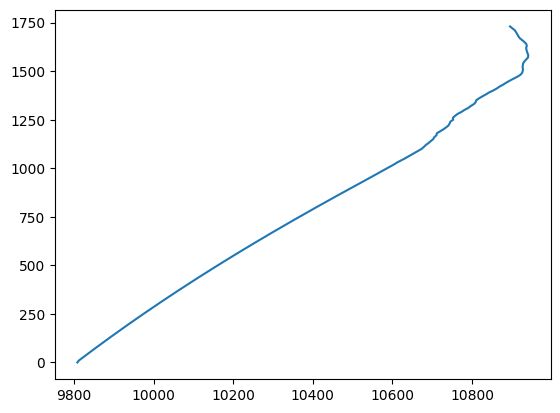

In [83]:
plt.plot(well_properties_bhp['Dp_dz'],well_properties_bhp['MD'])

In [ ]:
# ============================================================
# КОНСТАНТЫ И ПАРАМЕТРЫ
# ============================================================

# Standard conditions
Pstd = 101325  # Pa
Tstd = 273.15 + 20  # K

# Fluid properties
Ro_gas_std = 0.67  # кг/м3
Ro_water_std = 1000  # кг/м3
sigma = 0.072  # Н/м

# Well parameters
diameter = 0.1  # м
lyamda = 0.02

# Temperature profile
wellhead_temp = 293.15  # K
reservoir_temp = 305.15  # K

# Load inclinometry data
file_path_incl_horizontal = 'd:/Python_2025/Gas_liquid_flow/исходные_данные/vertical_well.dev'
with open(file_path_incl_horizontal, 'r', encoding='utf-8') as inclinometry_file_vertical:
    well_data_hor = pd.read_csv(inclinometry_file_vertical, comment='#', sep=r'\s+')

# Maximum TVD (глубина по вертикали) - bottom hole depth
max_TVD = well_data_hor['TVD'].iloc[-1]

# Load PVT data
file_path_pvt = 'd:/Python_2025/Gas_liquid_flow/исходные_данные/PVT.inc'
with open(file_path_pvt, 'r', encoding='utf-8') as pvt_file:
    pvt_data = pd.read_csv(pvt_file, comment='#', sep=r'\s+')

# Create fluid object
xa = 0.8858
xy = 0.0668
fluid_obj = fluid.Fluid(Ro_gas_std, xa, xy, pvt_data)

# ============================================================
# ВХОДНЫЕ ДАННЫЕ ДЛЯ VFP ТАБЛИЦЫ
# ============================================================

# Номер таблицы
table_number = 1

# Дебиты газа FLO (м3/сут) - в возрастающем порядке
gas_rates = np.array([30000, 50000, 100000, 200000])

# Устьевые давления THP (бар) - в возрастающем порядке
thp_bar = np.array([5, 30, 80])
thp_pa = thp_bar * 1e5

# Водогазовый фактор WFR (WGR) (м3/м3) - в возрастающем порядке
wgr_values = np.array([0.000001, 0.00001, 0.0001])

# GFR (OGR) - не используем, но нужно для формата
ogr_values = np.array([0.0])

# ALQ (GRAT) - не используем
grat_values = np.array([0.0])

# ============================================================
# ФУНКЦИЯ ДЛЯ РАСЧЁТА BHP ПО ИЗВЕСТНОМУ THP
# ============================================================

def calculate_bhp_from_thp(thp_pa, Q_gas_std_m3_per_day, wgr, well_data, 
                           diameter, lyamda, Ro_water_std, sigma, 
                           fluid_obj, wellhead_temp, reservoir_temp,
                           Pstd, Tstd, Ro_gas_std):
    """
    Расчёт забойного давления BHP по известному устьевому давлению THP.
    Возвращает BHP в барах.
    """
    
    # Конвертируем дебит газа в м3/с
    Q_gas_std = Q_gas_std_m3_per_day / 86400
    
    # Расход жидкости (воды) при стандартных условиях
    Q_water_std = Q_gas_std * wgr
    
    # Создаём копию данных для расчёта
    df = well_data.copy()
    
    # Заполняем температуру
    for idx in df.index:
        if idx == 0:
            df.loc[idx, 'T'] = wellhead_temp
        elif idx == len(df)-1:
            df.loc[idx, 'T'] = reservoir_temp
        else:
            df.loc[idx, 'T'] = reservoir_temp - (reservoir_temp - wellhead_temp) * (df.loc[idx, 'TVD'] / df['TVD'].iloc[-1])
    
    # Начальное давление на устье (первая точка)
    df.loc[0, 'P'] = thp_pa
    
    # Идём от устья к забою
    for idx in range(len(df)-1):
        pressure = df.loc[idx, 'P']
        temperature = df.loc[idx, 'T']
        alfa = df.loc[idx, 'INCL']
        
        # PVT свойства
        try:
            pressure_mpa = pressure / 1e6
            Bg = fluid_obj.get_Bg(pressure_mpa, temperature)
            if np.isnan(Bg) or np.isinf(Bg):
                Bg = 0.01
        except:
            Bg = 0.01
        
        # Плотность газа через Bg
        Ro_gas = Ro_gas_std / Bg
        
        # Расход газа при скважинных условиях
        Q_gas_pt = Q_gas_std * Bg
        
        # Площадь сечения
        area = np.pi * diameter**2 / 4
        
        # Скорости
        u_gas = Q_gas_pt / area if Q_gas_pt > 0 else 0
        
        if Q_water_std > 0:
            Q_water_pt = Q_water_std
            u_liq = Q_water_pt / area
        else:
            Q_water_pt = 0.0
            u_liq = 0.0
        
        # Расчёт градиента
        try:
            if alfa < 85:
                dp_dz = vniigaz_inclined(
                    lyamda, diameter, alfa,
                    u_liq, u_gas,
                    Ro_water_std, Ro_gas,
                    pressure, sigma,
                    Q_water_pt, Q_gas_pt
                )
            else:
                dp_dz = vniigaz_horizontal(
                    lyamda, diameter, alfa,
                    u_liq, u_gas,
                    Ro_water_std, Ro_gas,
                    pressure, sigma,
                    Q_water_pt, Q_gas_pt
                )
            
            if np.isnan(dp_dz) or np.isinf(dp_dz):
                dp_dz = 1000
        except:
            dp_dz = 1000
        
        # Переход к следующей точке
        delta_MD = df.loc[idx+1, 'MD'] - df.loc[idx, 'MD']
        pressure_next = pressure + dp_dz * delta_MD
        
        if np.isnan(pressure_next) or np.isinf(pressure_next):
            return 1e10
        
        df.loc[idx+1, 'P'] = pressure_next
        
        if pressure_next > 1e10:
            return 1e10
    
    # Возвращаем BHP в барах
    bhp_pa = df.loc[len(df)-1, 'P']
    bhp_bar = bhp_pa / 1e5
    
    return bhp_bar


# ============================================================
# РАСЧЁТ ВСЕХ КОМБИНАЦИЙ
# ============================================================

print("=" * 70)
print("ГЕНЕРАЦИЯ VFP ТАБЛИЦЫ")
print("=" * 70)
print(f"Таблица №{table_number}")
print(f"Глубина забоя: {max_TVD:.0f} м")
print(f"Дебиты газа (FLO): {gas_rates}")
print(f"Устьевые давления (THP): {thp_bar} бар")
print(f"Водогазовый фактор (WFR): {wgr_values}")
print("=" * 70)

# Размерности
NFLO = len(gas_rates)      # количество дебитов
NTHP = len(thp_bar)        # количество THP
NWFR = len(wgr_values)     # количество WFR
NGFR = len(ogr_values)     # количество GFR (у нас 1)
NALQ = len(grat_values)    # количество ALQ (у нас 1)

print(f"Всего комбинаций: {NTHP} × {NWFR} × {NGFR} × {NALQ} = {NTHP * NWFR * NGFR * NALQ}")
print(f"Каждая запись содержит {NFLO} значений BHP")
print(f"Всего расчётов: {NFLO * NTHP * NWFR * NGFR * NALQ}")
print("=" * 70)

# Массив для хранения результатов: [NTHP][NWFR][NGFR][NALQ][NFLO]
# Инициализируем массив BHP значениями 1e10 (признак ошибки)
bhp_results = np.full((NTHP, NWFR, NGFR, NALQ, NFLO), 1e10)

total_cases = NFLO * NTHP * NWFR * NGFR * NALQ
case_counter = 0

# Вложенные циклы по всем комбинациям
for i_thp in range(NTHP):
    thp = thp_bar[i_thp]
    for i_wfr in range(NWFR):
        wgr = wgr_values[i_wfr]
        for i_gfr in range(NGFR):
            ogr = ogr_values[i_gfr]  # не используется
            for i_alq in range(NALQ):
                grat = grat_values[i_alq]  # не используется
                
                # Для каждого дебита газа
                for i_flo in range(NFLO):
                    Q_gas = gas_rates[i_flo]
                    case_counter += 1
                    
                    print(f"Расчёт {case_counter}/{total_cases}: THP={thp} бар, Qgas={Q_gas} м3/сут, WGR={wgr:.6f}")
                    
                    try:
                        bhp = calculate_bhp_from_thp(
                            thp * 1e5, Q_gas, wgr, well_data_hor,
                            diameter, lyamda, Ro_water_std, sigma,
                            fluid_obj, wellhead_temp, reservoir_temp,
                            Pstd, Tstd, Ro_gas_std
                        )
                        bhp_results[i_thp, i_wfr, i_gfr, i_alq, i_flo] = bhp
                        print(f"  BHP = {bhp:.4f} бар")
                    except Exception as e:
                        print(f"  ОШИБКА: {e}")
                        bhp_results[i_thp, i_wfr, i_gfr, i_alq, i_flo] = 1e10

import pandas as pd

# После завершения всех расчётов, создаём DataFrame с подписями

# Получаем форму массива
NTHP, NWFR, NGFR, NALQ, NFLO = bhp_results.shape

# Создаём список для сбора данных
rows_data = []

# Заголовок для пояснения
print("Формирование VFP-подобной таблицы...")

for i_thp in range(NTHP):
    for i_wfr in range(NWFR):
        for i_gfr in range(NGFR):
            for i_alq in range(NALQ):
                # Получаем значения BHP для всех дебитов
                bhp_values = bhp_results[i_thp, i_wfr, i_gfr, i_alq, :]
                
                # Создаём строку с описанием параметров
                row = {
                    'THP_N': i_thp + 1,
                    'WFR_N': i_wfr + 1,
                    'GFR_N': i_gfr + 1,
                    'ALQ_N': i_alq + 1,
                    'THP_бар': thp_bar[i_thp],
                    'WGR_м3/м3': wgr_values[i_wfr],
                    'GFR_OGR': ogr_values[i_gfr],
                    'ALQ_GRAT': grat_values[i_alq]
                }
                
                # Добавляем BHP для каждого дебита газа
                for i_flo in range(NFLO):
                    row[f'BHP_FLO_{i_flo+1}_Qgas={gas_rates[i_flo]:.0f}'] = bhp_values[i_flo]
                
                rows_data.append(row)

import pandas as pd

# После завершения всех расчётов создаём DataFrame
rows_data = []

for i_thp in range(NTHP):
    for i_wfr in range(NWFR):
        for i_gfr in range(NGFR):
            for i_alq in range(NALQ):
                # Получаем BHP для всех дебитов
                bhp_values = bhp_results[i_thp, i_wfr, i_gfr, i_alq, :]
                
                # Строка с параметрами
                row = {
                    'THP_бар': thp_bar[i_thp],
                    'WGR_м3/м3': wgr_values[i_wfr],
                }
                
                # Добавляем BHP для каждого дебита
                for i_flo in range(NFLO):
                    row[f'Q={gas_rates[i_flo]:.0f}'] = round(bhp_values[i_flo], 4)
                
                rows_data.append(row)

# Создаём DataFrame
df_vfp = pd.DataFrame(rows_data)

# Просто выводим в консоль
print("\n" + "=" * 100)
print("VFP ТАБЛИЦА (BHP в барах)")
print("=" * 100)
print(df_vfp.to_string())
print("=" * 100)

# Если хочешь посмотреть в VSCode как таблицу
df_vfp


# ============================================================
# ЗАПИСЬ VFP ТАБЛИЦЫ В ФАЙЛ
# ============================================================

output_lines = []

# Строка 1: ключевое слово
output_lines.append("VFPPROD")

# Строка 2: основные данные таблицы
# номер_таблицы глубина_забоя тип_FLO тип_WFR тип_GFR тип_THP тип_ALQ единицы_измерения тип_данных
output_lines.append(
    f" {table_number} {max_TVD:.0f} GAS WGR OGR THP GRAT METRIC BHP /"
)

# Строка 3: значения FLO (дебиты газа)
flo_line = " " + " ".join([f"{q:.0f}" for q in gas_rates]) + " /"
output_lines.append(flo_line)

# Строка 4: значения THP (устьевые давления)
thp_line = " " + " ".join([f"{p:.0f}" for p in thp_bar]) + " /"
output_lines.append(thp_line)

# Строка 5: значения WFR (WGR)
wfr_line = " " + " ".join([f"{w:.6f}" for w in wgr_values]) + " /"
output_lines.append(wfr_line)

# Строка 6: значения GFR (OGR)
gfr_line = " " + " ".join([f"{g:.1f}" for g in ogr_values]) + " /"
output_lines.append(gfr_line)

# Строка 7: значения ALQ (GRAT)
alq_line = " " + " ".join([f"{a:.1f}" for a in grat_values]) + " /"
output_lines.append(alq_line)

# Строки с данными BHP
# Формат: NT NW NG NA BHP_1 BHP_2 ... BHP_NFLO /
print("\nЗапись результатов в файл...")

for i_thp in range(NTHP):
    for i_wfr in range(NWFR):
        for i_gfr in range(NGFR):
            for i_alq in range(NALQ):
                # Номера (индексация с 1)
                nt = i_thp + 1
                nw = i_wfr + 1
                ng = i_gfr + 1
                na = i_alq + 1
                
                # Значения BHP для всех дебитов газа
                bhp_values = bhp_results[i_thp, i_wfr, i_gfr, i_alq, :]
                
                # Форматируем строку
                bhp_str = " ".join([f"{bhp:.6f}" for bhp in bhp_values])
                data_line = f" {nt} {nw} {ng} {na} {bhp_str} /"
                output_lines.append(data_line)

# Сохраняем в файл
output_file = "vfp_table.inc"
with open(output_file, 'w', encoding='utf-8') as f:
    for line in output_lines:
        f.write(line + '\n')

print("\n" + "=" * 70)
print(f"VFP таблица сохранена в файл: {output_file}")
print(f"Количество строк в файле: {len(output_lines)}")
print("=" * 70)

# Выводим первые 15 строк для проверки
print("\nПервые 15 строк файла:")
print("-" * 70)
for i, line in enumerate(output_lines[:15]):
    print(line)
if len(output_lines) > 15:
    print("...")

# Выводим пример данных
print("\n" + "=" * 70)
print("ПРИМЕР ДАННЫХ В ТАБЛИЦЕ:")
print("=" * 70)
print(f"THP_1={thp_bar[0]} бар, WGR_1={wgr_values[0]:.6f}:")
for i_flo in range(NFLO):
    bhp = bhp_results[0, 0, 0, 0, i_flo]
    print(f"  Qgas={gas_rates[i_flo]:.0f} м3/сут -> BHP={bhp:.4f} бар")

ГЕНЕРАЦИЯ VFP ТАБЛИЦЫ
Таблица №1
Глубина забоя: 1200 м
Дебиты газа (FLO): [ 30000  50000 100000 200000]
Устьевые давления (THP): [ 5 30 80] бар
Водогазовый фактор (WFR): [1.e-06 1.e-05 1.e-04]
Всего комбинаций: 3 × 3 × 1 × 1 = 9
Каждая запись содержит 4 значений BHP
Всего расчётов: 36
Расчёт 1/36: THP=5 бар, Qgas=30000 м3/сут, WGR=0.000001
0.016663776169404464
0.015794825185472153
0.01615738409301296
0.016531987731059565
0.016919106015318854
0.017319230837299252
0.017732877220117595
0.018160584541560512
0.01860291782852727
0.01906046912723832
0.019533858953862622
0.0200237378305021
0.020530787911771094
0.02105572470752257
0.021599298907603464
0.022162298314865592
0.02274554989301922
0.023349921936290124
0.023976326368229085
0.024625721177424415
0.02529911299827842
0.025997559845431555
0.026722174010844504
0.027474125132980302
0.028254643447958812
0.02906502323297964
0.029906626452723618
0.03078088661983406
0.031689312880943635
0.03263349434003709
0.03361510463120924
0.03463590675308187

d:\Python_2025\Gas_liquid_flow\fluid.py:98: RuntimeWarning: invalid value encountered in scalar power
  A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
d:\Python_2025\Gas_liquid_flow\fluid.py:98: RuntimeWarning: invalid value encountered in scalar power
  A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
